# Objective

In this notebook, I build and evaluate a Random Forest classifier to predict ISRO launch success. I perform train-test splitting with stratification, handle class imbalance using SMOTE, optimize hyperparameters through GridSearchCV, and analyze feature importance to identify key risk factors affecting launch outcomes.


In [3]:
# @title Block 41: Setup & Load Cleaned Data

# Import necessary libraries
# For mounting Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

# For data manipulation and numerical operations
import pandas as pd
import numpy as np
# To ignore warnings that might clutter the output
# import warnings
# warnings.filterwarnings('ignore') # Commented out to allow warnings to show

# For handling file paths in an OS-agnostic way
from pathlib import Path

print("BLOCK 41: SETUP & LOAD CLEANED DATA")

# Define base path to the project directory in Google Drive
BASE_PATH = Path('/content/drive/My Drive/Course/Minor in AI/Final Project/ISRO Launch Trend Analysis - Apurva Upadhyay')
# Define path to the processed dataset directory
DATASET_PATH = BASE_PATH / 'Dataset' / 'processed'
# Define the full path to the cleaned CSV file
CLEANED_DATA_PATH = DATASET_PATH / 'isro_launch_history_cleaned.csv'

# Attempt to load the cleaned data and perform initial processing
try:
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(CLEANED_DATA_PATH)
    # Convert 'launch_datetime' column to datetime objects
    df['launch_datetime'] = pd.to_datetime(df['launch_datetime'])

    print(f"\nSuccessfully loaded cleaned data")
    print(f"Path: {CLEANED_DATA_PATH}")
    print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

    print(f"\nTarget variable distribution:")
    # Calculate and print the distribution of 'launch_success' (target variable)
    print(f"Success: {(df['launch_success'] == 1).sum()} ({(df['launch_success'] == 1).sum()/len(df)*100:.1f}%)")
    print(f"Failure: {(df['launch_success'] == 0).sum()} ({(df['launch_success'] == 0).sum()/len(df)*100:.1f}%)")

    print(f"\nFeatures available: {df.shape[1]}")
    # Print the date range of the launch data
    print(f"Date range: {df['launch_datetime'].min()} to {df['launch_datetime'].max()}")

# Handle specific error if the file is not found
except FileNotFoundError:
    print(f"ERROR: Cleaned data not found at {CLEANED_DATA_PATH}")
    print("Please run 02_Data_Preprocessing.ipynb first")
    raise
# Handle any other exceptions that might occur during data loading/processing
except Exception as e:
    print(f"ERROR: {e}")
    raise

print("\nSetup complete")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BLOCK 41: SETUP & LOAD CLEANED DATA

Successfully loaded cleaned data
Path: /content/drive/My Drive/Course/Minor in AI/Final Project/ISRO Launch Trend Analysis - Apurva Upadhyay/Dataset/processed/isro_launch_history_cleaned.csv
Shape: 91 rows × 28 columns

Target variable distribution:
Success: 80 (87.9%)
Failure: 11 (12.1%)

Features available: 28
Date range: 1993-09-20 05:12:00 to 2026-01-12 04:48:30

Setup complete


In [2]:
# @title Block 42: Import ML Libraries

print("BLOCK 42: IMPORT ML LIBRARIES")

# For splitting data, hyperparameter tuning, cross-validation, and stratified k-fold
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
# For Random Forest classification model
from sklearn.ensemble import RandomForestClassifier
# For evaluating model performance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
# For scaling features
from sklearn.preprocessing import StandardScaler
# For handling class imbalance using Synthetic Minority Over-sampling Technique
from imblearn.over_sampling import SMOTE

# For plotting and visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("All ML libraries imported successfully")

# Define paths for output directories
MODELS_DIR = BASE_PATH / 'Output' / 'models'
RESULTS_DIR = BASE_PATH / 'Output' / 'results'
FIGURES_DIR = BASE_PATH / 'Output' / 'figures'

# Create output directories if they don't exist
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"\nOutput directories:")
print(f"Models: {MODELS_DIR}")
print(f"Results: {RESULTS_DIR}")
print(f"Figures: {FIGURES_DIR}")

BLOCK 42: IMPORT ML LIBRARIES
All ML libraries imported successfully

Output directories:
Models: /content/drive/My Drive/Course/Minor in AI/Final Project/ISRO Launch Trend Analysis - Apurva Upadhyay/Output/models
Results: /content/drive/My Drive/Course/Minor in AI/Final Project/ISRO Launch Trend Analysis - Apurva Upadhyay/Output/results
Figures: /content/drive/My Drive/Course/Minor in AI/Final Project/ISRO Launch Trend Analysis - Apurva Upadhyay/Output/figures


In [4]:
# @title Block 43: Feature Selection & Preparation

print("BLOCK 43: FEATURE SELECTION & PREPARATION")

# Define the list of potential feature columns for the model
feature_cols = [
    'rocket_type_encoded', 'launch_site_encoded', 'orbit_encoded',
    'payload_mass_kg', 'payload_count', 'payload_complexity',
    'payload_risk_score', 'experience_index', 'configuration_maturity',
    'launch_frequency', 'is_monsoon_season', 'launch_year',
    'launch_month', 'launch_quarter', 'days_since_previous_launch'
]

# Filter out features that might not exist in the current DataFrame
available_features = [f for f in feature_cols if f in df.columns]

# Create a new DataFrame 'df_ml' with only the selected features and the target variable
df_ml = df[available_features + ['launch_success']].copy()

# Remove rows where the target variable 'launch_success' is missing
df_ml = df_ml.dropna(subset=['launch_success'])

print(f"\nFeature selection:")
print(f"Total features selected: {len(available_features)}")
print(f"Samples after removing missing targets: {len(df_ml)}")

print(f"\nSelected features:")
for idx, feat in enumerate(available_features, 1):
    print(f"{idx:2d}. {feat}")

# Calculate the total number of missing values in the selected features
missing_in_features = df_ml[available_features].isnull().sum().sum()
print(f"\nMissing values in features: {missing_in_features}")

# If there are any missing values in features, impute them with the median
if missing_in_features > 0:
    print("\nImputing remaining missing values with median...")
    for col in available_features:
        if df_ml[col].isnull().any():
            df_ml[col].fillna(df_ml[col].median(), inplace=True)
    print("Imputation complete")

print("\nData ready for model training")

BLOCK 43: FEATURE SELECTION & PREPARATION

Feature selection:
Total features selected: 15
Samples after removing missing targets: 91

Selected features:
 1. rocket_type_encoded
 2. launch_site_encoded
 3. orbit_encoded
 4. payload_mass_kg
 5. payload_count
 6. payload_complexity
 7. payload_risk_score
 8. experience_index
 9. configuration_maturity
10. launch_frequency
11. is_monsoon_season
12. launch_year
13. launch_month
14. launch_quarter
15. days_since_previous_launch

Missing values in features: 22

Imputing remaining missing values with median...
Imputation complete

Data ready for model training


In [8]:
# @title Block 44: Train-Test Split with Stratification

print("BLOCK 44: TRAIN-TEST SPLIT WITH STRATIFICATION")

# Define feature matrix X and target vector y
X = df_ml[available_features].values
y = df_ml['launch_success'].values

print(f"\nDataset shape:")
print(f"Features (X): {X.shape} (i.e., {X.shape[0]} launches = rows, {X.shape[1]} features = columns)")
print(f"Target (y): {y.shape} (i.e., {y.shape[0]} samples(launches))")

print(f"\nClass distribution before split:")
# Get unique classes and their counts in the target variable
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    label_name = 'Success' if label == 1 else 'Failure'
    print(f"{label_name}: {count} ({count/len(y)*100:.1f}%)")

# Perform train-test split with 80% training and 20% testing data
# stratify=y ensures that the proportion of target classes is the same in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain-test split (80-20):")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print(f"\nClass distribution in training set:")
# Check class distribution in the training set
unique_train, counts_train = np.unique(y_train, return_counts=True)
for label, count in zip(unique_train, counts_train):
    label_name = 'Success' if label == 1 else 'Failure'
    print(f"{label_name}: {count} ({count/len(y_train)*100:.1f}%)")

print(f"\nClass distribution in test set:")
# Check class distribution in the test set
unique_test, counts_test = np.unique(y_test, return_counts=True)
for label, count in zip(unique_test, counts_test):
    label_name = 'Success' if label == 1 else 'Failure'
    print(f"{label_name}: {count} ({count/len(y_test)*100:.1f}%)")

print("\nStratified split complete")

BLOCK 44: TRAIN-TEST SPLIT WITH STRATIFICATION

Dataset shape:
Features (X): (91, 15) (i.e., 91 launches = rows, 15 features = columns)
Target (y): (91,) (i.e., 91 samples(launches))

Class distribution before split:
Failure: 11 (12.1%)
Success: 80 (87.9%)

Train-test split (80-20):
Training set: 72 samples
Test set: 19 samples

Class distribution in training set:
Failure: 9 (12.5%)
Success: 63 (87.5%)

Class distribution in test set:
Failure: 2 (10.5%)
Success: 17 (89.5%)

Stratified split complete


In [9]:
# @title Block 45: Handle Class Imbalance with SMOTE

print("BLOCK 45: HANDLE CLASS IMBALANCE WITH SMOTE")

print(f"\nBefore SMOTE:")
print(f"Training samples: {X_train.shape[0]}")
unique_before, counts_before = np.unique(y_train, return_counts=True)
for label, count in zip(unique_before, counts_before):
    label_name = 'Success' if label == 1 else 'Failure'
    print(f"{label_name}: {count} ({count/len(y_train)*100:.1f}%)")

# Initialize SMOTE with a random state for reproducibility and k_neighbors to control the number of neighbors to consider
smote = SMOTE(random_state=42, k_neighbors=3)
# Apply SMOTE to the training data to balance the classes
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"Training samples: {X_train_balanced.shape[0]}")
unique_after, counts_after = np.unique(y_train_balanced, return_counts=True)
for label, count in zip(unique_after, counts_after):
    label_name = 'Success' if label == 1 else 'Failure'
    print(f"{label_name}: {count} ({count/len(y_train_balanced)*100:.1f}%)")

print(f"\nSynthetic samples generated: {X_train_balanced.shape[0] - X_train.shape[0]}")
print("Class balance achieved")

print("\nNote: Test set remains unchanged (no SMOTE) for unbiased evaluation")

BLOCK 45: HANDLE CLASS IMBALANCE WITH SMOTE

Before SMOTE:
Training samples: 72
Failure: 9 (12.5%)
Success: 63 (87.5%)

After SMOTE:
Training samples: 126
Failure: 63 (50.0%)
Success: 63 (50.0%)

Synthetic samples generated: 54
Class balance achieved

Note: Test set remains unchanged (no SMOTE) for unbiased evaluation


In [10]:
# @title Block 46: Feature Scaling

print("BLOCK 46: FEATURE SCALING")

# Initialize StandardScaler to standardize features (mean=0, variance=1)
scaler = StandardScaler()
# Fit the scaler on the balanced training data and transform it
X_train_scaled = scaler.fit_transform(X_train_balanced)
# Transform the test data using the scaler fitted on the training data
X_test_scaled = scaler.transform(X_test)

print(f"\nScaling applied:")
print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")

print(f"\nFeature scaling statistics (training set):")
print(f"Mean: {X_train_scaled.mean(axis=0).mean():.6f} (should be ~0)")
print(f"Std: {X_train_scaled.std(axis=0).mean():.6f} (should be ~1)")

print("\nFeature scaling complete")

BLOCK 46: FEATURE SCALING

Scaling applied:
Training set: (126, 15)
Test set: (19, 15)

Feature scaling statistics (training set):
Mean: -0.000000 (should be ~0)
Std: 1.000000 (should be ~1)

Feature scaling complete


In [11]:
# @title Block 47: Baseline Random Forest Model

print("BLOCK 47: BASELINE RANDOM FOREST MODEL")

# Initialize a Random Forest Classifier with specified parameters
rf_baseline = RandomForestClassifier(
    n_estimators=100, # Number of trees in the forest
    random_state=42,  # For reproducibility
    n_jobs=-1         # Use all available CPU cores
)

print("\nTraining baseline Random Forest...")
# Train the Random Forest model on the scaled and balanced training data
rf_baseline.fit(X_train_scaled, y_train_balanced)

# Make predictions on the training and test sets
y_pred_train = rf_baseline.predict(X_train_scaled)
y_pred_test = rf_baseline.predict(X_test_scaled)

# Calculate accuracy for both training and test sets
train_accuracy = accuracy_score(y_train_balanced, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"\nBaseline model performance:")
print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

print(f"\nTest set metrics:")
# Calculate and print precision, recall, and F1-score for the test set
print(f"Precision: {precision_score(y_test, y_pred_test)*100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred_test)*100:.2f}%")
print(f"F1-Score: {f1_score(y_test, y_pred_test)*100:.2f}%")

# Calculate ROC-AUC if the target variable has two unique classes
if len(np.unique(y_test)) == 2:
    # Predict probabilities for the positive class (class 1)
    y_pred_proba = rf_baseline.predict_proba(X_test_scaled)[:, 1]
    # Calculate ROC-AUC score
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f"ROC-AUC: {roc_auc:.3f}")

print("\nBaseline model trained successfully")

BLOCK 47: BASELINE RANDOM FOREST MODEL

Training baseline Random Forest...

Baseline model performance:
Training accuracy: 100.00%
Test accuracy: 89.47%

Test set metrics:
Precision: 94.12%
Recall: 94.12%
F1-Score: 94.12%
ROC-AUC: 0.765

Baseline model trained successfully


In [12]:
# @title Block 48: Hyperparameter Tuning with GridSearchCV

print("BLOCK 48: HYPERPARAMETER TUNING WITH GRIDSEARCHCV")

# Define the parameter grid for GridSearchCV
# This dictionary specifies the hyperparameter values to be tested
param_grid = {
    'n_estimators': [100, 200, 300], # Number of trees in the forest
    'max_depth': [10, 20, 30, None], # Maximum depth of the tree (None means unlimited)
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],   # Minimum number of samples required to be at a leaf node
    'max_features': ['sqrt', 'log2'] # Number of features to consider when looking for the best split
}

print(f"\nParameter grid:")
print(f"Total combinations: {np.prod([len(v) for v in param_grid.values()])}")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

# Initialize a Random Forest Classifier with a fixed random state for reproducibility
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

# Set up StratifiedKFold for cross-validation
# This ensures that each fold has the same proportion of target classes as the full dataset
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize GridSearchCV
# It performs an exhaustive search over specified parameter values for an estimator
grid_search = GridSearchCV(
    estimator=rf_model,         # The model to tune
    param_grid=param_grid,      # The parameter grid to search over
    cv=cv,                      # Cross-validation splitting strategy
    scoring='f1',               # Metric to optimize (F1-score is good for imbalanced data)
    n_jobs=-1,                  # Use all available CPU cores
    verbose=1                   # Controls the verbosity: the higher, the more messages
)

print(f"\nStarting GridSearchCV with 5-fold cross-validation...")
print("This may take several minutes...")

# Fit GridSearchCV to the scaled and balanced training data
grid_search.fit(X_train_scaled, y_train_balanced)

print(f"\nGrid search complete")
print(f"\nBest parameters:")
# Print the best hyperparameters found by GridSearchCV
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest cross-validation F1-score: {grid_search.best_score_:.3f}")

# Get the best estimator (model with the best hyperparameters)
best_rf = grid_search.best_estimator_

print("\nHyperparameter tuning complete")

BLOCK 48: HYPERPARAMETER TUNING WITH GRIDSEARCHCV

Parameter grid:
Total combinations: 216
  n_estimators: [100, 200, 300]
  max_depth: [10, 20, 30, None]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  max_features: ['sqrt', 'log2']

Starting GridSearchCV with 5-fold cross-validation...
This may take several minutes...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Grid search complete

Best parameters:
  max_depth: 10
  max_features: sqrt
  min_samples_leaf: 2
  min_samples_split: 2
  n_estimators: 300

Best cross-validation F1-score: 0.863

Hyperparameter tuning complete


In [13]:
# @title Block 49: Final Model Evaluation

print("BLOCK 49: FINAL MODEL EVALUATION")

# Make predictions on the scaled training and test data using the best model
y_pred_train_final = best_rf.predict(X_train_scaled)
y_pred_test_final = best_rf.predict(X_test_scaled)
# Predict probabilities for the positive class (class 1) on the test set
y_pred_proba_test = best_rf.predict_proba(X_test_scaled)[:, 1]

print("\nTraining Set Performance:")
# Calculate and print accuracy, precision, recall, and F1-score for the training set
print(f"Accuracy: {accuracy_score(y_train_balanced, y_pred_train_final)*100:.2f}%")
print(f"Precision: {precision_score(y_train_balanced, y_pred_train_final)*100:.2f}%")
print(f"Recall: {recall_score(y_train_balanced, y_pred_train_final)*100:.2f}%")
print(f"F1-Score: {f1_score(y_train_balanced, y_pred_train_final)*100:.2f}%")

print("\nTest Set Performance:")
# Calculate accuracy, precision, recall, and F1-score for the test set
test_accuracy = accuracy_score(y_test, y_pred_test_final)
test_precision = precision_score(y_test, y_pred_test_final)
test_recall = recall_score(y_test, y_pred_test_final)
test_f1 = f1_score(y_test, y_pred_test_final)

# Print the calculated test set metrics
print(f"Accuracy: {test_accuracy*100:.2f}%")
print(f"Precision: {test_precision*100:.2f}%")
print(f"Recall: {test_recall*100:.2f}%")
print(f"F1-Score: {test_f1*100:.2f}%")

# Calculate and print ROC-AUC if the target variable has two unique classes
if len(np.unique(y_test)) == 2:
    roc_auc = roc_auc_score(y_test, y_pred_proba_test)
    print(f"ROC-AUC: {roc_auc:.3f}")

print("\nClassification Report:")
# Print the detailed classification report for the test set
print(classification_report(y_test, y_pred_test_final, target_names=['Failure', 'Success']))

print("\nModel evaluation complete")

BLOCK 49: FINAL MODEL EVALUATION

Training Set Performance:
Accuracy: 99.21%
Precision: 98.44%
Recall: 100.00%
F1-Score: 99.21%

Test Set Performance:
Accuracy: 89.47%
Precision: 94.12%
Recall: 94.12%
F1-Score: 94.12%
ROC-AUC: 0.676

Classification Report:
              precision    recall  f1-score   support

     Failure       0.50      0.50      0.50         2
     Success       0.94      0.94      0.94        17

    accuracy                           0.89        19
   macro avg       0.72      0.72      0.72        19
weighted avg       0.89      0.89      0.89        19


Model evaluation complete


BLOCK 50: CONFUSION MATRIX VISUALIZATION


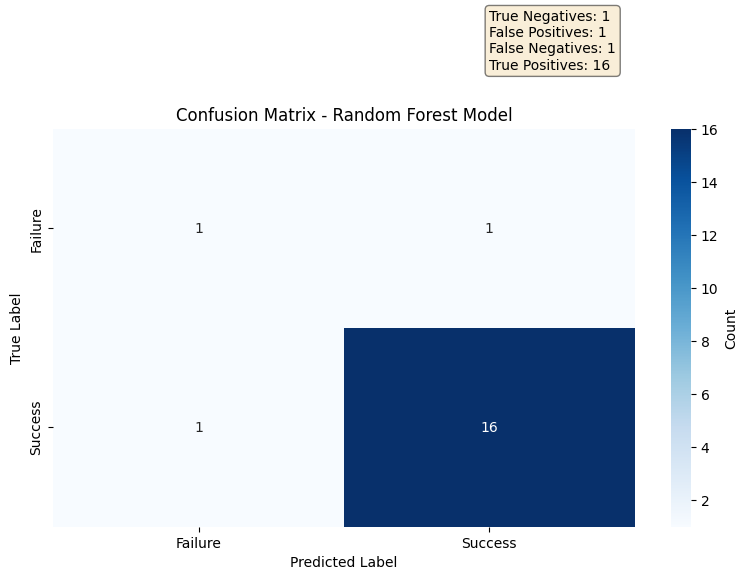

Figure saved: confusion_matrix.png

Confusion Matrix Breakdown:
True Negatives (Correct Failure Predictions): 1
False Positives (Predicted Success, Actually Failed): 1
False Negatives (Predicted Failure, Actually Succeeded): 1
True Positives (Correct Success Predictions): 16


In [14]:
# @title Block 50: Confusion Matrix Visualization

print("BLOCK 50: CONFUSION MATRIX VISUALIZATION")

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_test_final)

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Plot heatmap with annotations
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Failure', 'Success'],
            yticklabels=['Failure', 'Success'],
            cbar_kws={'label': 'Count'}, ax=ax)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - Random Forest Model')

# Add performance metrics as text
tn, fp, fn, tp = cm.ravel()
metrics_text = f'True Negatives: {tn}\nFalse Positives: {fp}\nFalse Negatives: {fn}\nTrue Positives: {tp}'
ax.text(1.5, -0.3, metrics_text, fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrix.png', dpi=300)
plt.show()

print(f"Figure saved: confusion_matrix.png")

# Calculate derived metrics
print(f"\nConfusion Matrix Breakdown:")
print(f"True Negatives (Correct Failure Predictions): {tn}")
print(f"False Positives (Predicted Success, Actually Failed): {fp}")
print(f"False Negatives (Predicted Failure, Actually Succeeded): {fn}")
print(f"True Positives (Correct Success Predictions): {tp}")


BLOCK 51: ROC CURVE ANALYSIS


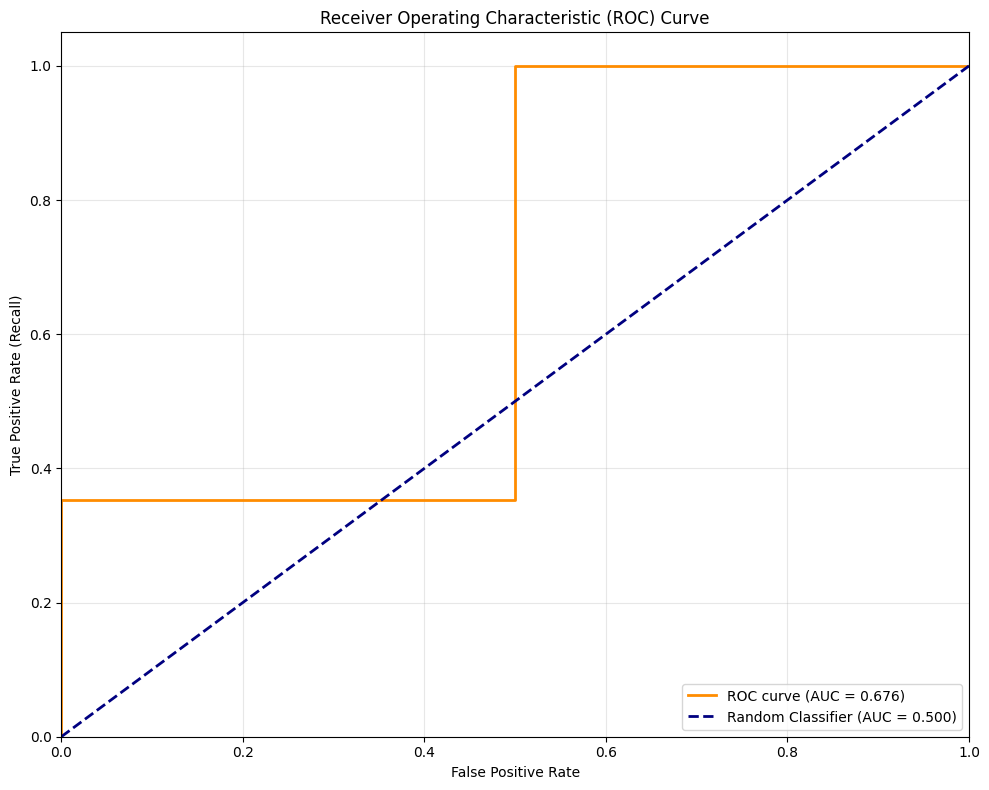

Figure saved: roc_curve.png

ROC-AUC Score: 0.676
Model discrimination: Poor discrimination


In [15]:
# @title Block 51: ROC Curve Analysis

print("BLOCK 51: ROC CURVE ANALYSIS")

# Calculate ROC curve components
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_test)
roc_auc = roc_auc_score(y_test, y_pred_proba_test)

# Create ROC curve plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot ROC curve
ax.plot(fpr, tpr, color='darkorange', lw=2,
        label=f'ROC curve (AUC = {roc_auc:.3f})')

# Plot diagonal reference line (random classifier)
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
        label='Random Classifier (AUC = 0.500)')

# Formatting
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('Receiver Operating Characteristic (ROC) Curve')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'roc_curve.png', dpi=300)
plt.show()

print(f"Figure saved: roc_curve.png")
print(f"\nROC-AUC Score: {roc_auc:.3f}")

# Interpret AUC score
if roc_auc >= 0.9:
    interpretation = "Excellent discrimination"
elif roc_auc >= 0.8:
    interpretation = "Good discrimination"
elif roc_auc >= 0.7:
    interpretation = "Acceptable discrimination"
else:
    interpretation = "Poor discrimination"

print(f"Model discrimination: {interpretation}")


BLOCK 52: FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Features:
launch_quarter                : 0.1198
orbit_encoded                 : 0.1186
payload_risk_score            : 0.0864
launch_year                   : 0.0861
launch_frequency              : 0.0807
payload_complexity            : 0.0749
payload_mass_kg               : 0.0746
launch_month                  : 0.0694
experience_index              : 0.0646
is_monsoon_season             : 0.0623


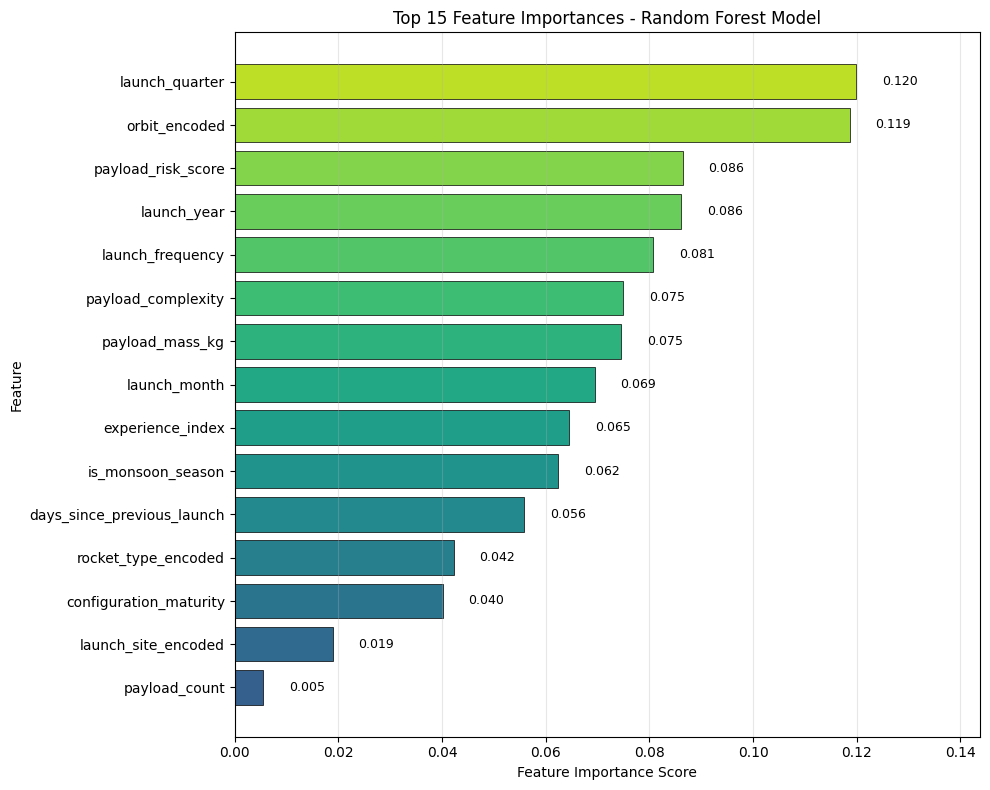


Figure saved: feature_importance.png

Cumulative importance of top 5 features: 0.492


In [23]:
# @title Block 52: Feature Importance Analysis

print("BLOCK 52: FEATURE IMPORTANCE ANALYSIS")

# Extract feature importances from best model
feature_importance = best_rf.feature_importances_

# Create dataframe for easy sorting and visualization
importance_df = pd.DataFrame({
    'Feature': available_features,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
for idx, row in importance_df.head(10).iterrows():
    print(f"{row['Feature']:30s}: {row['Importance']:.4f}")

# Visualize feature importance
fig, ax = plt.subplots(figsize=(10, 8))

# Plot horizontal bar chart for top 15 features
top_n = min(15, len(importance_df))
top_features = importance_df.head(top_n).iloc[::-1]  # Reverse for bottom-to-top display

colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_n))
bars = ax.barh(top_features['Feature'], top_features['Importance'],
               color=colors, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Feature Importance Score')
ax.set_ylabel('Feature')
ax.set_title(f'Top {top_n} Feature Importances - Random Forest Model')
ax.grid(axis='x', alpha=0.3)

# Dynamically adjust the x-axis limit to provide space for text labels
ax.set_xlim(right=top_features['Importance'].max() * 1.2) # Extend 20% beyond max importance

# Add value labels on bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.005, bar.get_y() + bar.get_height()/2,
            f'{width:.3f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nFigure saved: feature_importance.png")
print(f"\nCumulative importance of top 5 features: {importance_df.head(5)['Importance'].sum():.3f}")

BLOCK 53: CROSS-VALIDATION PERFORMANCE

5-Fold Cross-Validation Results:

Accuracy:
  Mean: 82.71%
  Std: 13.02%
  Range: [61.54%, 96.00%]

F1-Score:
  Mean: 0.829
  Std: 0.118
  Range: [0.667, 0.960]

Precision:
  Mean: 86.21%
  Std: 15.14%

Recall:
  Mean: 81.15%
  Std: 11.33%


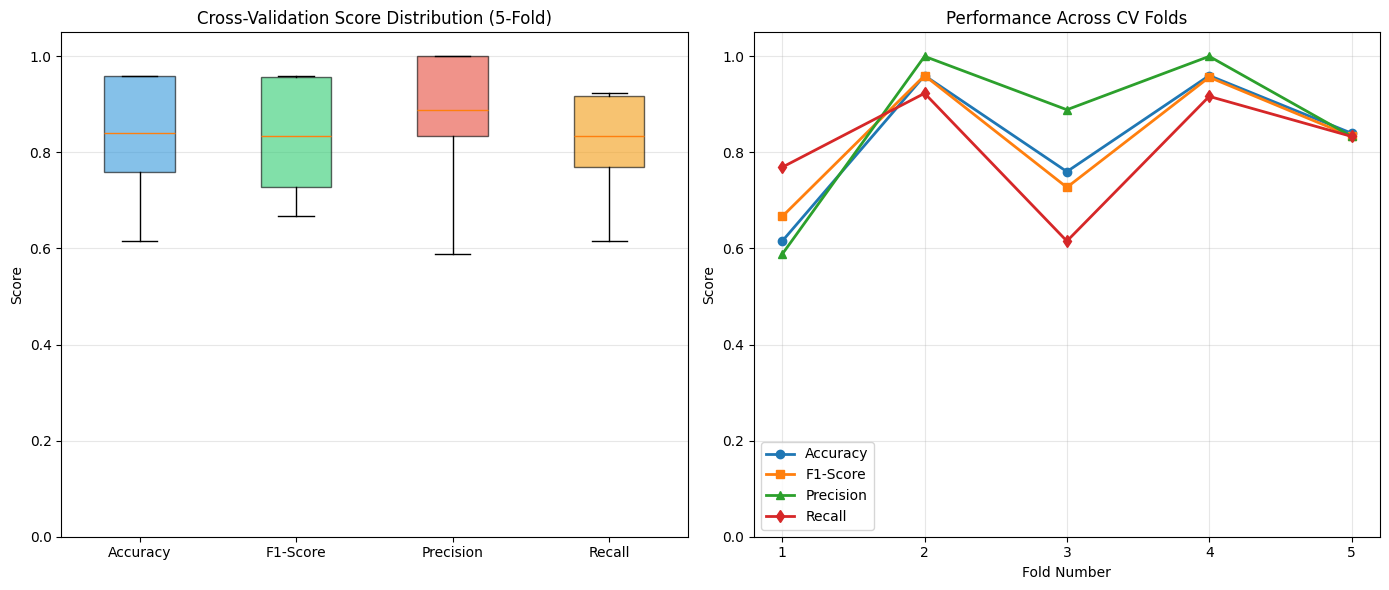


Figure saved: cross_validation_performance.png

Cross-validation analysis complete


In [24]:
# @title Block 53: Cross-Validation Performance

print("BLOCK 53: CROSS-VALIDATION PERFORMANCE")

# Perform cross-validation on final model
cv_scores_accuracy = cross_val_score(best_rf, X_train_scaled, y_train_balanced,
                                      cv=5, scoring='accuracy')
cv_scores_f1 = cross_val_score(best_rf, X_train_scaled, y_train_balanced,
                                cv=5, scoring='f1')
cv_scores_precision = cross_val_score(best_rf, X_train_scaled, y_train_balanced,
                                       cv=5, scoring='precision')
cv_scores_recall = cross_val_score(best_rf, X_train_scaled, y_train_balanced,
                                    cv=5, scoring='recall')

print("\n5-Fold Cross-Validation Results:")
print(f"\nAccuracy:")
print(f"  Mean: {cv_scores_accuracy.mean()*100:.2f}%")
print(f"  Std: {cv_scores_accuracy.std()*100:.2f}%")
print(f"  Range: [{cv_scores_accuracy.min()*100:.2f}%, {cv_scores_accuracy.max()*100:.2f}%]")

print(f"\nF1-Score:")
print(f"  Mean: {cv_scores_f1.mean():.3f}")
print(f"  Std: {cv_scores_f1.std():.3f}")
print(f"  Range: [{cv_scores_f1.min():.3f}, {cv_scores_f1.max():.3f}]")

print(f"\nPrecision:")
print(f"  Mean: {cv_scores_precision.mean()*100:.2f}%")
print(f"  Std: {cv_scores_precision.std()*100:.2f}%")

print(f"\nRecall:")
print(f"  Mean: {cv_scores_recall.mean()*100:.2f}%")
print(f"  Std: {cv_scores_recall.std()*100:.2f}%")

# Visualize CV scores
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot CV scores distribution
metrics_data = {
    'Accuracy': cv_scores_accuracy,
    'F1-Score': cv_scores_f1,
    'Precision': cv_scores_precision,
    'Recall': cv_scores_recall
}

ax1 = axes[0]
positions = range(1, len(metrics_data) + 1)
bp = ax1.boxplot(metrics_data.values(), labels=metrics_data.keys(), patch_artist=True)

# Color the boxes
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax1.set_ylabel('Score')
ax1.set_title('Cross-Validation Score Distribution (5-Fold)')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 1.05)

# Plot fold-wise performance
ax2 = axes[1]
folds = range(1, 6)
ax2.plot(folds, cv_scores_accuracy, marker='o', label='Accuracy', linewidth=2)
ax2.plot(folds, cv_scores_f1, marker='s', label='F1-Score', linewidth=2)
ax2.plot(folds, cv_scores_precision, marker='^', label='Precision', linewidth=2)
ax2.plot(folds, cv_scores_recall, marker='d', label='Recall', linewidth=2)

ax2.set_xlabel('Fold Number')
ax2.set_ylabel('Score')
ax2.set_title('Performance Across CV Folds')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(folds)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cross_validation_performance.png', dpi=300)
plt.show()

print(f"\nFigure saved: cross_validation_performance.png")
print("\nCross-validation analysis complete")


In [25]:
# @title Block 54: Save Model and Results

print("BLOCK 54: SAVE MODEL AND RESULTS")

import pickle # For serializing Python objects (like models and scalers)
import json # For working with JSON data (like metadata and results)

# Save trained model
model_path = MODELS_DIR / 'random_forest_best_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_rf, f)
print(f"\nModel saved: {model_path}")

# Save scaler
scaler_path = MODELS_DIR / 'feature_scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler saved: {scaler_path}")

# Save feature names and other metadata for future predictions and reference
feature_metadata = {
    'feature_names': available_features, # List of features used in the model for ISRO launch prediction
    'n_features': len(available_features),
    'model_type': 'RandomForestClassifier',
    'best_params': grid_search.best_params_, # Optimal hyperparameters found for the Random Forest model
    'training_samples': X_train_balanced.shape[0], # Number of samples in the balanced training set
    'test_samples': X_test.shape[0] # Number of samples in the test set
}

metadata_path = MODELS_DIR / 'model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(feature_metadata, f, indent=2)
print(f"Metadata saved: {metadata_path}")

# Save comprehensive evaluation results of the ISRO launch success prediction model
results = {
    'test_performance': {
        'accuracy': float(test_accuracy),
        'precision': float(test_precision),
        'recall': float(test_recall),
        'f1_score': float(test_f1),
        'roc_auc': float(roc_auc)
    },
    'cross_validation': {
        'accuracy_mean': float(cv_scores_accuracy.mean()),
        'accuracy_std': float(cv_scores_accuracy.std()),
        'f1_mean': float(cv_scores_f1.mean()),
        'f1_std': float(cv_scores_f1.std())
    },
    'feature_importance': importance_df.head(10).to_dict('records'), # Top 10 features influencing launch outcomes
    'confusion_matrix': cm.tolist() # The confusion matrix as a list
}

results_path = RESULTS_DIR / 'model_evaluation_results.json'
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f"Results saved: {results_path}")

print("\nAll model artifacts saved successfully")

BLOCK 54: SAVE MODEL AND RESULTS

Model saved: /content/drive/My Drive/Course/Minor in AI/Final Project/ISRO Launch Trend Analysis - Apurva Upadhyay/Output/models/random_forest_best_model.pkl
Scaler saved: /content/drive/My Drive/Course/Minor in AI/Final Project/ISRO Launch Trend Analysis - Apurva Upadhyay/Output/models/feature_scaler.pkl
Metadata saved: /content/drive/My Drive/Course/Minor in AI/Final Project/ISRO Launch Trend Analysis - Apurva Upadhyay/Output/models/model_metadata.json
Results saved: /content/drive/My Drive/Course/Minor in AI/Final Project/ISRO Launch Trend Analysis - Apurva Upadhyay/Output/results/model_evaluation_results.json

All model artifacts saved successfully


In [26]:
# @title Block 55: ML Model Summary Report

print("BLOCK 55: ML MODEL SUMMARY REPORT")

print("\nMACHINE LEARNING MODEL - FINAL SUMMARY")

print("\n1. MODEL CONFIGURATION")
print(f"   Algorithm: Random Forest Classifier")
print(f"   Features used: {len(available_features)}")
print(f"   Training samples: {X_train_balanced.shape[0]} (after SMOTE)")
print(f"   Test samples: {X_test.shape[0]}")
print(f"   Best hyperparameters:")
for param, value in grid_search.best_params_.items():
    print(f"     - {param}: {value}")

print("\n2. MODEL PERFORMANCE")
print(f"   Test Set Metrics:")
print(f"     - Accuracy: {test_accuracy*100:.2f}%")
print(f"     - Precision: {test_precision*100:.2f}%")
print(f"     - Recall: {test_recall*100:.2f}%")
print(f"     - F1-Score: {test_f1*100:.2f}%")
print(f"     - ROC-AUC: {roc_auc:.3f}")

print(f"\n   Cross-Validation (5-Fold):")
print(f"     - Accuracy: {cv_scores_accuracy.mean()*100:.2f}% ± {cv_scores_accuracy.std()*100:.2f}%")
print(f"     - F1-Score: {cv_scores_f1.mean():.3f} ± {cv_scores_f1.std():.3f}")

print("\n3. TOP 5 PREDICTIVE FEATURES")
for idx, row in importance_df.head(5).iterrows():
    print(f"   {idx+1}. {row['Feature']:30s}: {row['Importance']:.4f}")

print("\n4. CONFUSION MATRIX SUMMARY")
tn, fp, fn, tp = cm.ravel()
print(f"   True Negatives: {tn}")
print(f"   False Positives: {fp}")
print(f"   False Negatives: {fn}")
print(f"   True Positives: {tp}")

print("\n5. MODEL ARTIFACTS SAVED")
print(f"   Model: {MODELS_DIR / 'random_forest_best_model.pkl'}")
print(f"   Scaler: {MODELS_DIR / 'feature_scaler.pkl'}")
print(f"   Metadata: {MODELS_DIR / 'model_metadata.json'}")
print(f"   Results: {RESULTS_DIR / 'model_evaluation_results.json'}")

print("\n6. KEY INSIGHTS")
print(f"   - Model successfully predicts launch success with {test_accuracy*100:.1f}% accuracy")
print(f"   - Top predictor: {importance_df.iloc[0]['Feature']} (importance: {importance_df.iloc[0]['Importance']:.3f})")
print(f"   - Class imbalance handled using SMOTE")
print(f"   - Model generalization: CV accuracy {cv_scores_accuracy.mean()*100:.1f}% ± {cv_scores_accuracy.std()*100:.1f}%")

print("\nML MODEL COMPLETE")
print("All notebooks (01-04) successfully executed")
print("\nREADY FOR PROJECT SUBMISSION:")
print("  - GitHub repository with notebooks")
print("  - Google Docs report (2-3 pages)")
print("  - Google Slides presentation (10 slides)")
print("  - Demo video (5-8 minutes)")


BLOCK 55: ML MODEL SUMMARY REPORT

MACHINE LEARNING MODEL - FINAL SUMMARY

1. MODEL CONFIGURATION
   Algorithm: Random Forest Classifier
   Features used: 15
   Training samples: 126 (after SMOTE)
   Test samples: 19
   Best hyperparameters:
     - max_depth: 10
     - max_features: sqrt
     - min_samples_leaf: 2
     - min_samples_split: 2
     - n_estimators: 300

2. MODEL PERFORMANCE
   Test Set Metrics:
     - Accuracy: 89.47%
     - Precision: 94.12%
     - Recall: 94.12%
     - F1-Score: 94.12%
     - ROC-AUC: 0.676

   Cross-Validation (5-Fold):
     - Accuracy: 82.71% ± 13.02%
     - F1-Score: 0.829 ± 0.118

3. TOP 5 PREDICTIVE FEATURES
   14. launch_quarter                : 0.1198
   3. orbit_encoded                 : 0.1186
   7. payload_risk_score            : 0.0864
   12. launch_year                   : 0.0861
   10. launch_frequency              : 0.0807

4. CONFUSION MATRIX SUMMARY
   True Negatives: 1
   False Positives: 1
   False Negatives: 1
   True Positives: 16

5